<style>
  h1, h2, h3, p, li, div { font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; }
  h1 { color: #0b0b0b; border-bottom: 3px solid #2a78d6; padding-bottom: 10px; margin-bottom: 6px; font-size: 1.9em; }
  h2 { color: #2a78d6; font-size: 1.2em; margin-top: 1.4em; margin-bottom: 0.4em; }
  code { background: #f4f3f0; padding: 1px 5px; border-radius: 3px; font-size: 0.9em; }
  .op-sub { color: #898781; font-size: 0.92em; }
</style>

# Under-30 Federal Law Enforcement
<span class="op-sub">One-pager · Source: OPM/EHRI (<code>impactproject/opm-ehri-data</code> on HuggingFace) · Full methodology, source screenshots, and monthly detail: <code>fleo_under30.ipynb</code></span>


In [1]:
import sys
sys.path.insert(0, "src")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

from headline import compute_headline, VALIDATED_METHOD, PROVISIONAL_MONTH_FMT, PROVISIONAL_MONTH, as_dt_index

con = duckdb.connect()
con.execute("SET enable_progress_bar=false;")

SERIES_COLOR, SERIES2_COLOR, MUTED = "#2a78d6", "#eb6834", "#898781"

def style_ax(ax, ylabel=None):
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.yaxis.grid(True, color="#e1e0d9", linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#0b0b0b", labelsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)

H = compute_headline(con)
hc_latest, u30_latest, vs_bjs = H["hc_latest"], H["u30_latest"], H["vs_bjs"]
vs_gao_0083 = H["vs_gao_0083"]
hires_m, seps_m = H["hires_m"], H["seps_m"]
hires_yr = H["hires_yr"]
hires_ttm, hc_ttm_avg = H["hires_ttm"], H["hc_ttm_avg"]
attr_rate_ttm, allage_attr_rate_ttm, attr_ratio_ttm = H["attr_rate_ttm"], H["allage_attr_rate_ttm"], H["attr_ratio_ttm"]
M = VALIDATED_METHOD

prior_ttm_month = f"{int(PROVISIONAL_MONTH[:4]) - 1}{PROVISIONAL_MONTH[4:]}"
hires_ttm_now, hires_ttm_prior = hires_ttm.loc[PROVISIONAL_MONTH], hires_ttm.loc[prior_ttm_month]
hires_ttm_yoy_pct = 100 * (hires_ttm_now - hires_ttm_prior) / hires_ttm_prior
hires_max_yr, hires_max_val = hires_yr.loc[:"2025"].idxmax(), hires_yr.loc[:"2025"].max()
hires_ttm_vs_max_pct = 100 * (hires_ttm_now - hires_max_val) / hires_max_val
attr_now = attr_rate_ttm.loc[PROVISIONAL_MONTH]


In [2]:
display(Markdown(f'''
## Bottom line
**As of {PROVISIONAL_MONTH_FMT}, ~{u30_latest[M]/1000:.0f},000 federal law enforcement officers are under 30
({100*u30_latest[M]/hc_latest[M]:.1f}% of ~{hc_latest[M]/1000:.0f},000 total)** -- job series definition (Police,
US Marshal, Criminal Investigator, General Investigator, Border Patrol, CBP Officer,
Correctional Officer; any pay plan), validated within **{abs(vs_bjs[M]):.0f}% of BJS's
independent census total** and **{abs(vs_gao_0083):.0f}% of GAO's independently audited
Police-series count** -- the two closest outside checks available. Two other candidate
definitions were tested and rejected (missed those same benchmarks by
{abs(vs_bjs["pay_plan"]):.0f}% and {abs(vs_bjs["broad_series"]):.0f}%).

**Year over year:** in the 12 months ending {PROVISIONAL_MONTH_FMT} (real trailing data, not a
projection), under-30 hiring (~{hires_ttm_now:,.0f}) is up {hires_ttm_yoy_pct:.0f}% from the same window a
year earlier and already {hires_ttm_vs_max_pct:.0f}% above the best full calendar year on record ({hires_max_val:,.0f},
{hires_max_yr}). Under-30 **attrition is not elevated**: {attr_now:.1f}% sits well inside its
historical range, not at a new high. The one constant: under-30 officers leave at
**{attr_ratio_ttm.min():.2f}-{attr_ratio_ttm.max():.2f}x** the all-ages rate, every month checked -- a structural gap, not a
new development.
'''))



## Bottom line
**As of 2026-07, ~16,000 federal law enforcement officers are under 30
(12.8% of ~125,000 total)** -- job series definition (Police,
US Marshal, Criminal Investigator, General Investigator, Border Patrol, CBP Officer,
Correctional Officer; any pay plan), validated within **7% of BJS's
independent census total** and **2% of GAO's independently audited
Police-series count** -- the two closest outside checks available. Two other candidate
definitions were tested and rejected (missed those same benchmarks by
73% and 78%).

**Year over year:** in the 12 months ending 2026-07 (real trailing data, not a
projection), under-30 hiring (~7,112) is up 49% from the same window a
year earlier and already 40% above the best full calendar year on record (5,086,
2025). Under-30 **attrition is not elevated**: 8.5% sits well inside its
historical range, not at a new high. The one constant: under-30 officers leave at
**1.19-1.62x** the all-ages rate, every month checked -- a structural gap, not a
new development.


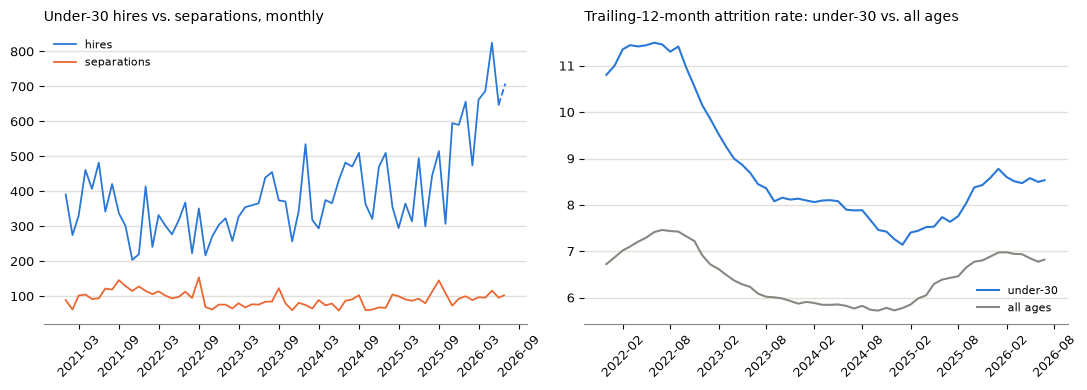

In [3]:
# Real monthly data throughout -- no annual bucketing, no partial-year projection.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

hires_dt, seps_dt = as_dt_index(hires_m), as_dt_index(seps_m)
axes[0].plot(hires_dt.index[:-1], hires_dt.values[:-1], color=SERIES_COLOR, linewidth=1.3, label="hires")
axes[0].plot(hires_dt.index[-2:], hires_dt.values[-2:], color=SERIES_COLOR, linewidth=1.3, linestyle="--")
axes[0].plot(seps_dt.index[:-1], seps_dt.values[:-1], color=SERIES2_COLOR, linewidth=1.3, label="separations")
axes[0].plot(seps_dt.index[-2:], seps_dt.values[-2:], color=SERIES2_COLOR, linewidth=1.3, linestyle="--")
axes[0].set_title("Under-30 hires vs. separations, monthly", fontsize=10, loc="left")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")

attr_dt, allage_dt = as_dt_index(attr_rate_ttm), as_dt_index(allage_attr_rate_ttm)
axes[1].plot(attr_dt.index[:-1], attr_dt.values[:-1], color=SERIES_COLOR, linewidth=1.5, label="under-30")
axes[1].plot(attr_dt.index[-2:], attr_dt.values[-2:], color=SERIES_COLOR, linewidth=1.5, linestyle="--")
axes[1].plot(allage_dt.index[:-1], allage_dt.values[:-1], color=MUTED, linewidth=1.5, label="all ages")
axes[1].plot(allage_dt.index[-2:], allage_dt.values[-2:], color=MUTED, linewidth=1.5, linestyle="--")
axes[1].set_title("Trailing-12-month attrition rate: under-30 vs. all ages", fontsize=10, loc="left")
axes[1].legend(frameon=False, fontsize=8, loc="lower right")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    style_ax(ax)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45)
plt.tight_layout()
plt.show()


In [4]:
import datetime

display(Markdown(f'''
<hr style="border:none; border-top:1px solid #e1e0d9; margin-top:22px;">
<span class="op-sub">Both external benchmarks (BJS/GAO) are backed by source-report screenshots in
<code>sources/</code> -- see <code>fleo_under30.ipynb</code> &sect;1b. Definitions, validation, monthly
detail, and caveats (provisional latest month, no cohort-survival data, etc.) are all
there too. Generated {datetime.date.today():%Y-%m-%d}.</span>
'''))



<hr style="border:none; border-top:1px solid #e1e0d9; margin-top:22px;">
<span class="op-sub">Both external benchmarks (BJS/GAO) are backed by source-report screenshots in
<code>sources/</code> -- see <code>fleo_under30.ipynb</code> &sect;1b. Definitions, validation, monthly
detail, and caveats (provisional latest month, no cohort-survival data, etc.) are all
there too. Generated 2026-09-14.</span>
